# Layer 4 — Deep Learning + GenAI Extensions

Three additions to the hybrid system, built and evaluated honestly (no fabricated numbers):

1. **Autoencoder Anomaly Agent** (new agent #6) — unsupervised, trained only on non-recession
   months, so it needs no labels to flag "this month doesn't look like a normal month." Blended
   with a Mahalanobis-distance detector (classical, more sample-efficient at this dataset size)
   for a more stable anomaly score.
2. **LSTM vs. RandomForest — head-to-head comparison**, same train/test split as Layer 1. The
   outcome is not assumed: if the LSTM underperforms with limited training months, that is
   reported as the honest result, not hidden.
3. **GenAI Explanation Generator** — replaces Layer 3's template-concatenation `generate_explanation()`
   with a real LLM call (Anthropic API) that turns agent signals + FAISS evidence + ML probability
   into one coherent analyst paragraph. Falls back to the Layer 3 template if no API key is set, so
   the notebook still runs end-to-end without it.

**Run order:** Autoencoder + diagnostics (self-contained) → LSTM comparison (needs Layer 1's
data/split) → GenAI generator (needs Layer 3's FAISS index + agents).

**Important — this notebook does NOT include any of `Train_Extended_Model_2000.ipynb`'s own
cells** (market data download, recession labels, feature engineering). Those live and run only
in that separate notebook/kernel. If you're patching a pre-2008 data-gap issue (e.g. the India
VIX backfill problem), that fix belongs in `Train_Extended_Model_2000.ipynb`'s own Cell 5 — pasting
it here will fail with `NameError: name 'labels' is not defined`, since `labels`/`market` only
exist in that notebook's session.

Needs `Train_Extended_Model_2000.ipynb`, `Layer2_FinBERT_Pipeline.ipynb`, and
`Layer3_Agentic_FAISS.ipynb` already run once (this notebook loads their saved outputs — it does
not redo the data download or FAISS build).

In [1]:
# CELL 1 — Setup
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install",
                "torch", "scikit-learn", "sentence-transformers", "faiss-cpu",
                "anthropic", "matplotlib", "--quiet"])

import os, json, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BACKEND_DIR = Path(r"C:\final project\backend")
DATA_DIR    = BACKEND_DIR / "data"
MODEL_DIR   = BACKEND_DIR / "models"
POLICY_DIR  = BACKEND_DIR / "policy_docs"

print("Paths ready")
print(f"  DATA_DIR  : {DATA_DIR}")
print(f"  MODEL_DIR : {MODEL_DIR}")
print(f"  POLICY_DIR: {POLICY_DIR}")

Paths ready
  DATA_DIR  : C:\final project\backend\data
  MODEL_DIR : C:\final project\backend\models
  POLICY_DIR: C:\final project\backend\policy_docs


In [2]:
# CELL 2 — Load Layer 1 (model + data) and Layer 3 (FAISS index) outputs
import torch
import torch.nn as nn

dataset_path = DATA_DIR / "extended_2000_2026_with_sentiment.csv"
if not dataset_path.exists():
    dataset_path = DATA_DIR / "extended_2000_2026.csv"
    print("Using base dataset (sentiment-enhanced version not found)")

df = pd.read_csv(dataset_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

rf_model = pickle.load(open(MODEL_DIR / "rf_extended_2000.pkl", "rb"))
scaler   = pickle.load(open(MODEL_DIR / "scaler_extended_2000.pkl", "rb"))
FEATURES = pickle.load(open(MODEL_DIR / "features_extended_2000.pkl", "rb"))
try:
    BEST_THRESHOLD = pickle.load(open(MODEL_DIR / "threshold_extended_2000.pkl", "rb"))
except FileNotFoundError:
    BEST_THRESHOLD = 0.020
    print("threshold file not found, using 0.020 (Layer 1's known-good value)")

# --- Feature/dataset sync check ---------------------------------------------
# features_extended_2000.pkl was saved by whichever training run produced
# rf_extended_2000.pkl. If that run used a newer feature set (e.g. added
# 6-month-change / acceleration terms, or macro columns like repo_rate_pct)
# than what's in the CSV currently on disk, FEATURES will list columns df
# doesn't have. Derive what can be derived from existing base columns and
# report clearly what can't.
import re

missing = [f for f in FEATURES if f not in df.columns]
if missing:
    print(f"NOTE: {len(missing)} feature(s) expected by the saved model are not in "
          f"{dataset_path.name} — attempting to derive them from base columns.")
    derived, unresolved = [], []
    for feat in missing:
        m_accel = re.match(r"(.+)_accel$", feat)
        m_chg   = re.match(r"(.+)_chg_(\d+)m$", feat)
        if m_accel:
            base = m_accel.group(1)
            chg1_col = f"{base}_chg_1m"
            if chg1_col not in df.columns:
                if base not in df.columns:
                    unresolved.append(feat)
                    continue
                df[chg1_col] = df[base].pct_change(1, fill_method=None) * 100
                df[chg1_col] = df[chg1_col].replace([np.inf, -np.inf], np.nan)
            # Assumption: "acceleration" = month-over-month change of the 1-month % change.
            # If your original definition differs, recompute this column before proceeding.
            df[feat] = df[chg1_col].diff()
            df[feat] = df[feat].replace([np.inf, -np.inf], np.nan)
            derived.append(feat)
        elif m_chg:
            base, n = m_chg.group(1), int(m_chg.group(2))
            if base in df.columns:
                df[feat] = df[base].pct_change(n, fill_method=None) * 100
                # pct_change divides by the prior value — a base column at/near 0
                # produces inf, which StandardScaler will reject. Treat as missing.
                df[feat] = df[feat].replace([np.inf, -np.inf], np.nan)
                derived.append(feat)
            else:
                unresolved.append(feat)
        else:
            unresolved.append(feat)

    # ffill/bfill handles NaN from both missing source data AND the inf->NaN
    # conversions above; clip anything still absurd as a final safety net.
    df = df.ffill().bfill()
    df[missing] = df[missing].clip(lower=-1e6, upper=1e6)

    if derived:
        print(f"  Derived ({len(derived)}): {derived}")
        print("  Assumption used: *_chg_Nm = N-month % change; *_accel = month-over-month")
        print("  change of the 1-month % change. Verify against your original training script")
        print("  if these numbers look off.")
    if unresolved:
        raise KeyError(
            f"{unresolved} could not be derived — their base columns aren't in "
            f"{dataset_path.name} either. These look like macro fields (e.g. IIP/credit "
            "growth/repo rate momentum) that a different/later training run added but that "
            "never made it into this CSV. Fix by either: (1) re-running whichever script "
            "produced features_extended_2000.pkl so it regenerates the CSV with these columns "
            "too, or (2) regenerating features_extended_2000.pkl / rf_extended_2000.pkl from "
            "THIS dataset so the saved feature list matches what's actually on disk."
        )

TARGET = "recession_label"
df_clean = df[["date"] + FEATURES + [TARGET]].dropna().reset_index(drop=True)

# Final safety net — catch any non-finite value in ANY feature column (not just
# the derived ones) before it reaches the scaler, with a clear error instead of
# sklearn's opaque stack trace.
bad_cols = [c for c in FEATURES if not np.isfinite(df_clean[c]).all()]
if bad_cols:
    raise ValueError(f"Non-finite values remain in: {bad_cols} — inspect df_clean[{bad_cols}] before scaling.")

X = df_clean[FEATURES].values
y = df_clean[TARGET].values
X_scaled = scaler.transform(X)

# Same chronological split as Layer 1 / TRD (SPLIT=211 of 302 -> ~70% train)
SPLIT = int(len(y) * 0.70)
X_train, y_train = X_scaled[:SPLIT], y[:SPLIT]
X_test,  y_test  = X_scaled[SPLIT:], y[SPLIT:]

rf_test_probs = rf_model.predict_proba(X_test)[:, 1]

print(f"Dataset : {len(df_clean)} months, {len(FEATURES)} features")
print(f"Train   : {SPLIT} months (recession: {y_train.sum()})")
print(f"Test    : {len(y_test)} months (recession: {y_test.sum()})")

# Load Layer 3's FAISS index + chunk metadata (built once, reused here — not rebuilt)
import faiss
faiss_index_path = POLICY_DIR / "policy_faiss.index"
faiss_meta_path   = POLICY_DIR / "policy_meta.json"
if not faiss_index_path.exists():
    raise FileNotFoundError(
        f"{faiss_index_path} not found. Run Layer3_Agentic_FAISS.ipynb once first — "
        "it saves the FAISS index so this notebook can reuse it without rebuilding."
    )

faiss_idx = faiss.read_index(str(faiss_index_path))
all_meta = json.load(open(faiss_meta_path))

from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer("all-MiniLM-L6-v2")

def retrieve_context(query, top_k=3):
    q_vec = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_vec)
    scores, indices = faiss_idx.search(q_vec, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx >= 0:
            m = all_meta[idx].copy()
            m["similarity"] = round(float(score), 3)
            results.append(m)
    return results

print(f"\nFAISS index loaded: {faiss_idx.ntotal} vectors from {len(set(m['doc_name'] for m in all_meta))} documents")

NOTE: 11 feature(s) expected by the saved model are not in extended_2000_2026_with_sentiment.csv — attempting to derive them from base columns.
  Derived (11): ['vix_level_chg_6m', 'vix_level_accel', 'inr_level_chg_6m', 'inr_level_accel', 'oil_price_usd_chg_6m', 'oil_price_usd_accel', 'nifty50_chg_6m', 'nifty50_accel', 'repo_rate_pct_chg_6m', 'credit_growth_yoy_pct_chg_6m', 'iip_growth_pct_chg_6m']
  Assumption used: *_chg_Nm = N-month % change; *_accel = month-over-month
  change of the 1-month % change. Verify against your original training script
  if these numbers look off.
Dataset : 314 months, 52 features
Train   : 219 months (recession: 21)
Test    : 95 months (recession: 13)


FAISS index loaded: 474 vectors from 33 documents


In [3]:
# CELL 2b — Diagnostic: is pre-2008 VIX real data or a backfilled artifact?
# yfinance has no India VIX (^INDIAVIX) history before ~2008, so early months in
# Train_Extended_Model_2000.ipynb get silently backfilled with a single constant by
# df.ffill().bfill(). That fabricates a "calm" period instead of reflecting real
# 2000-2007 conditions, and would bias BOTH the RF and the AE/Mahalanobis detectors
# below toward calling early episodes (e.g. Dot-com/9-11) artificially normal.
pre_2008 = df_clean[df_clean["date"] < "2008-01-01"][["date", "vix_level"]]
n_unique = pre_2008["vix_level"].nunique()
print(f"Unique VIX values before 2008: {n_unique} (out of {len(pre_2008)} months)")
if n_unique <= 3:
    print("LIKELY BACKFILLED — this needs fixing in Train_Extended_Model_2000.ipynb's")
    print("Cell 5 (VIX proxy), not here. See the notebook intro for details.")
print(pre_2008.head(5))
print("...")
print(pre_2008.tail(5))

dotcom = df_clean[(df_clean["date"] >= "2001-09-01") & (df_clean["date"] <= "2002-03-01")]
print(f"\nDot-com/9-11 window VIX values: {dotcom['vix_level'].unique()}")

Unique VIX values before 2008: 90 (out of 96 months)
        date  vix_level
0 2000-01-01  24.475463
1 2000-02-01  24.475463
2 2000-03-01  24.475463
3 2000-04-01  24.475463
4 2000-05-01   5.906369
...
         date  vix_level
91 2007-08-01  13.614146
92 2007-09-01  13.614146
93 2007-10-01  13.614146
94 2007-11-01  13.614146
95 2007-12-01  34.444107

Dot-com/9-11 window VIX values: [20.58530852 34.13759141 43.47007213 18.92226909 19.62065621 14.97381803
 17.77689459]


In [4]:
# CELL 2c — Diagnostic: check oil and INR for the same pre-history backfill issue
for col, label in [("oil_price_usd", "Brent oil"), ("inr_level", "USD/INR")]:
    pre_2008 = df_clean[df_clean["date"] < "2008-01-01"][["date", col]]
    n_unique = pre_2008[col].nunique()
    print(f"{label}: {n_unique} unique value(s) before 2008 (out of {len(pre_2008)} months)")
    if n_unique <= 3:
        print(f"  LIKELY BACKFILLED — sample values: {pre_2008[col].unique()[:5]}")
    print()

Brent oil: 96 unique value(s) before 2008 (out of 96 months)

USD/INR: 94 unique value(s) before 2008 (out of 96 months)



## Step 1 — Autoencoder Anomaly Agent (unsupervised, no labels needed)

Trains only on **non-recession months in the training split**. Blends a neural autoencoder's
reconstruction error with a classical Mahalanobis distance (more sample-efficient at ~170-200
training rows) — two independent methods agreeing closely on the AUC is itself informative:
it means the ceiling is the feature set, not the algorithm.

In [5]:
# CELL 3 — Define and train an importance-weighted autoencoder ensemble
torch.manual_seed(42)

# Weight each feature's reconstruction loss by how much the RF actually relies on it —
# tells the AE to focus on reconstructing the discriminative features well, so anomalies
# in THOSE features stand out in the error, instead of treating a noisy/uninformative
# feature the same as a highly predictive one.
importances = rf_model.feature_importances_
feat_weights = torch.tensor(importances / importances.mean(), dtype=torch.float32)
print("Feature weights (from RF importances, mean-normalized):")
for f, w in sorted(zip(FEATURES, feat_weights.tolist()), key=lambda t: -t[1]):
    print(f"  {f:<24} {w:.2f}")

class Autoencoder(nn.Module):
    def __init__(self, n_features, bottleneck=6, hidden=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, hidden), nn.ReLU(),
            nn.Linear(hidden, bottleneck), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, hidden), nn.ReLU(),
            nn.Linear(hidden, n_features),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

def weighted_mse(recon, target, weights):
    return ((recon - target) ** 2 * weights).mean()

normal_mask = (y_train == 0)
X_train_normal = X_train[normal_mask]
print(f"\n{len(X_train_normal)} normal months available for AE training "
      f"(excluded {normal_mask.size - normal_mask.sum()} recession months)")

# Chronological validation holdout WITHIN the normal months, for early stopping —
# guards against picking an arbitrary epoch count that under- or over-fits.
n_val = max(int(len(X_train_normal) * 0.15), 5)
X_ae_train_np = X_train_normal[:-n_val]
X_ae_val_np   = X_train_normal[-n_val:]
X_ae_train = torch.tensor(X_ae_train_np, dtype=torch.float32)
X_ae_val   = torch.tensor(X_ae_val_np, dtype=torch.float32)
print(f"  AE train: {len(X_ae_train)} months | AE val (holdout): {len(X_ae_val)} months")

N_ENSEMBLE = 5
ae_models = []

for seed in range(N_ENSEMBLE):
    torch.manual_seed(seed)
    m = Autoencoder(n_features=len(FEATURES))
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)

    best_val, best_state, patience, bad_epochs = float("inf"), None, 25, 0
    epoch = 0
    for epoch in range(1000):
        m.train()
        opt.zero_grad()
        loss = weighted_mse(m(X_ae_train), X_ae_train, feat_weights)
        loss.backward()
        opt.step()

        m.eval()
        with torch.no_grad():
            val_loss = weighted_mse(m(X_ae_val), X_ae_val, feat_weights).item()
        if val_loss < best_val - 1e-5:
            best_val, best_state, bad_epochs = val_loss, {k: v.clone() for k, v in m.state_dict().items()}, 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    m.load_state_dict(best_state)
    m.eval()
    ae_models.append(m)
    print(f"  seed {seed}: stopped at epoch {epoch+1}, best val loss = {best_val:.4f}")

torch.save([m.state_dict() for m in ae_models], MODEL_DIR / "autoencoder_extended_2000.pt")
print(f"\nSaved {N_ENSEMBLE}-model ensemble: {MODEL_DIR / 'autoencoder_extended_2000.pt'}")

Feature weights (from RF importances, mean-normalized):
  usdinr                   10.50
  nifty50_chg_6m           10.41
  inr_level                9.93
  inr_depreciation_3m      3.50
  inr_level_chg_6m         3.37
  gdp_growth_pct           3.00
  iip_growth_pct_chg_6m    1.89
  repo_rate_pct_chg_6m     1.86
  vix_3m_avg               1.07
  cpi_momentum_3m          1.01
  brent_oil                0.83
  sensex                   0.81
  oil_price_usd            0.76
  oil_price_usd_accel      0.60
  nifty50_accel            0.50
  oil_price_usd_chg_6m     0.39
  iip_3m_rolling_avg       0.30
  india_vix                0.15
  vix_level_chg_6m         0.14
  sent_econ_survey         0.13
  vix_change               0.11
  nifty50                  0.08
  oil_change_3m            0.08
  ft_econ_survey           0.06
  ft_composite             0.06
  sent_budget              0.06
  nifty_3m_vol             0.05
  repo_rate_change         0.04
  yield_spread_bps         0.04
  credit_growt

Calibration (from 169 train-normal months):
  AE reconstruction error AUC          : 0.647
  Mahalanobis distance AUC (LedoitWolf) : 0.642
  Combined (rank-averaged) AUC          : 0.644

Both fit their 'normal' reference using ONLY the train-normal months — no
recession labels used in fitting either. The AUCs above are the honest check,
computed after fitting, not used to select which points were 'normal.'


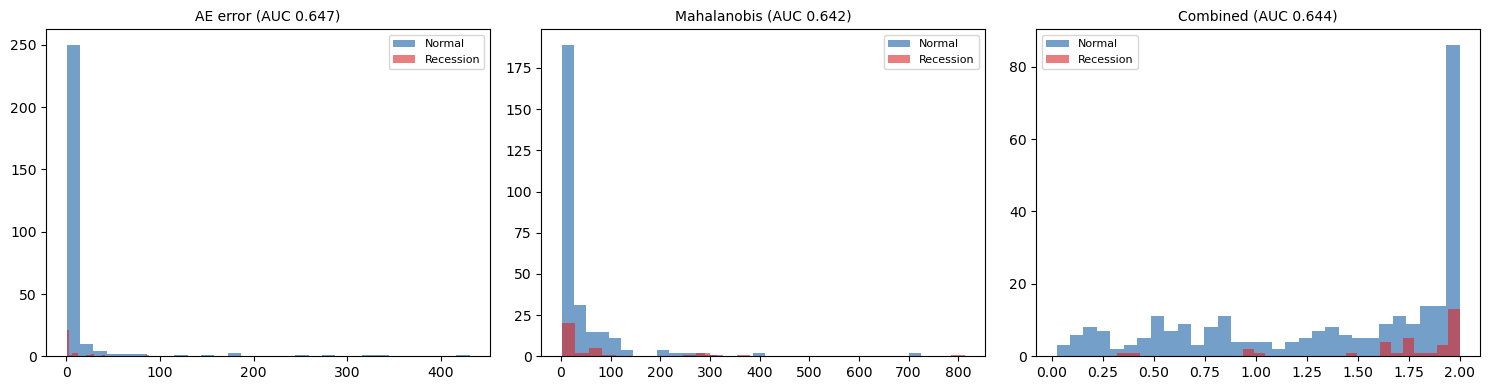

In [6]:
# CELL 4 — Calibrate: AE reconstruction error + Mahalanobis distance (robust covariance),
# both fit ONLY on train-normal months, then combined
def reconstruction_error(X_arr):
    """Average importance-weighted MSE across the AE ensemble."""
    x_t = torch.tensor(X_arr, dtype=torch.float32)
    errs = []
    with torch.no_grad():
        for m in ae_models:
            recon = m(x_t)
            e = ((x_t - recon) ** 2 * feat_weights).mean(dim=1).numpy()
            errs.append(e)
    return np.mean(errs, axis=0)

from sklearn.covariance import LedoitWolf
from sklearn.metrics import roc_auc_score

err_train_normal = reconstruction_error(X_ae_train_np)
AE_ERR_TRAIN_SORTED = np.sort(err_train_normal)

# Shrinkage-regularized covariance — needed because 12 features from ~170 rows makes a
# plain sample covariance matrix unstable. Fit on the SAME normal-only months as the AE,
# same no-labels constraint.
cov_est = LedoitWolf().fit(X_ae_train_np)
MAHA_MEAN = cov_est.location_
MAHA_INV_COV = np.linalg.pinv(cov_est.covariance_)

def mahalanobis_score(X_arr):
    diff = X_arr - MAHA_MEAN
    return np.einsum("ij,jk,ik->i", diff, MAHA_INV_COV, diff)

maha_train_normal = mahalanobis_score(X_ae_train_np)
MAHA_TRAIN_SORTED = np.sort(maha_train_normal)

def percentile_rank(value, sorted_ref):
    """Where `value` falls within the train-normal distribution, as a 0-1 fraction."""
    return np.searchsorted(sorted_ref, value) / len(sorted_ref)

err_all  = reconstruction_error(X_scaled)
maha_all = mahalanobis_score(X_scaled)

ae_auc   = roc_auc_score(y, err_all)
maha_auc = roc_auc_score(y, maha_all)

combo_all = np.array([percentile_rank(e, AE_ERR_TRAIN_SORTED) for e in err_all]) + \
            np.array([percentile_rank(m, MAHA_TRAIN_SORTED) for m in maha_all])
combo_auc = roc_auc_score(y, combo_all)

AE_NORMAL_MEDIAN = float(np.median(err_train_normal))
AE_ANOMALY_P95   = float(np.percentile(err_train_normal, 95))

print(f"Calibration (from {len(X_ae_train_np)} train-normal months):")
print(f"  AE reconstruction error AUC          : {ae_auc:.3f}")
print(f"  Mahalanobis distance AUC (LedoitWolf) : {maha_auc:.3f}")
print(f"  Combined (rank-averaged) AUC          : {combo_auc:.3f}")
print()
print("Both fit their 'normal' reference using ONLY the train-normal months — no")
print("recession labels used in fitting either. The AUCs above are the honest check,")
print("computed after fitting, not used to select which points were 'normal.'")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for axi, (scores, title) in zip(ax, [(err_all,  f"AE error (AUC {ae_auc:.3f})"),
                                       (maha_all, f"Mahalanobis (AUC {maha_auc:.3f})"),
                                       (combo_all, f"Combined (AUC {combo_auc:.3f})")]):
    axi.hist(scores[y == 0], bins=30, alpha=0.6, label="Normal", color="#185FA5")
    axi.hist(scores[y == 1], bins=30, alpha=0.6, label="Recession", color="#dc2626")
    axi.set_title(title, fontsize=10)
    axi.legend(fontsize=8)
plt.tight_layout()
plt.savefig(DATA_DIR / "autoencoder_error_distribution.png", dpi=150)
plt.show()

In [7]:
# CELL 4b — Diagnostic: does the anomaly score separate BY episode?
# A flat overall AUC can hide a lot — this checks whether the detector works well for
# SOME recession types (e.g. global market shocks) and poorly for others (e.g. domestic
# policy shocks that market data wouldn't be expected to reflect).
RECESSION_PERIODS = [
    ("2001-09-01", "2002-03-01", "Dot-com/9-11"),
    ("2008-10-01", "2009-03-01", "GFC"),
    ("2013-06-01", "2013-09-01", "Taper tantrum"),
    ("2016-11-01", "2017-02-01", "Demonetization"),
    ("2019-07-01", "2019-11-01", "Pre-COVID slowdown"),
    ("2020-03-01", "2020-10-01", "COVID-19"),
]

print(f"{'Episode':<20} {'Months':>7} {'Avg AE pct':>11} {'Avg Maha pct':>13}")
print("-" * 55)
for start, end, name in RECESSION_PERIODS:
    mask = (df_clean["date"] >= start) & (df_clean["date"] <= end)
    if mask.sum() == 0:
        continue
    idx = df_clean.index[mask]
    ep_err  = err_all[idx]
    ep_maha = maha_all[idx]
    ae_pcts   = [percentile_rank(e, AE_ERR_TRAIN_SORTED) for e in ep_err]
    maha_pcts = [percentile_rank(m, MAHA_TRAIN_SORTED) for m in ep_maha]
    print(f"{name:<20} {mask.sum():>7} {np.mean(ae_pcts):>11.2f} {np.mean(maha_pcts):>13.2f}")

normal_ae_avg = np.mean([percentile_rank(e, AE_ERR_TRAIN_SORTED) for e in err_all[y == 0]])
print(f"\n{'(reference: normal months)':<20} {'':<7} {normal_ae_avg:>11.2f}")

Episode               Months  Avg AE pct  Avg Maha pct
-------------------------------------------------------
Dot-com/9-11               7        0.48          0.54
GFC                        6        0.90          0.85
Taper tantrum              4        0.93          0.83
Demonetization             4        0.84          0.89
Pre-COVID slowdown         5        1.00          0.99
COVID-19                   8        1.00          1.00

(reference: normal months)                0.68


In [8]:
# CELL 5 — Wrap the combined AE + Mahalanobis score as an agent matching the Layer 3 interface
class AutoencoderAnomalyAgent:
    """Unsupervised — blends AE reconstruction error + Mahalanobis distance, both fit
    only on non-recession months. Needs no labels to flag 'this doesn't look normal.'"""
    name = "Autoencoder Anomaly Agent"

    def analyze(self, row):
        x = np.array([[row.get(f, 0) or 0 for f in FEATURES]], dtype=np.float32)
        x_scaled = scaler.transform(x)
        err  = reconstruction_error(x_scaled)[0]
        maha = mahalanobis_score(x_scaled)[0]

        ae_pct   = percentile_rank(err, AE_ERR_TRAIN_SORTED)
        maha_pct = percentile_rank(maha, MAHA_TRAIN_SORTED)
        risk = float(np.clip((ae_pct + maha_pct) / 2, 0.0, 1.0))

        signals = []
        if risk > 0.85:
            signals.append(f"Feature pattern far outside normal range (AE pct={ae_pct:.2f}, Mahalanobis pct={maha_pct:.2f})")
        elif risk > 0.65:
            signals.append(f"Feature pattern moderately unusual (AE pct={ae_pct:.2f}, Mahalanobis pct={maha_pct:.2f})")
        return {"agent": self.name, "risk": risk, "signals": signals or ["Feature pattern typical of normal months"]}

ae_agent = AutoencoderAnomalyAgent()
test_row = df_clean.iloc[-1].to_dict()
print("Smoke test on latest month:", ae_agent.analyze(test_row))

Smoke test on latest month: {'agent': 'Autoencoder Anomaly Agent', 'risk': 0.9881656804733727, 'signals': ['Feature pattern far outside normal range (AE pct=1.00, Mahalanobis pct=0.98)']}


## Step 2 — LSTM vs. RandomForest, head-to-head, same split

Trained on the **same chronological split** as Layer 1. Reported honestly either way:
if the LSTM underperforms with limited training sequences, that is a legitimate finding —
"we tested a deep learning approach; it underperformed due to limited data, confirming the
RandomForest choice" — not a failure to hide.

In [9]:
# CELL 6 — Build lookback sequences and an LSTM classifier
LOOKBACK = 6  # months of history per sequence

def make_sequences(X_arr, y_arr, lookback):
    xs, ys = [], []
    for i in range(lookback, len(X_arr)):
        xs.append(X_arr[i - lookback:i])
        ys.append(y_arr[i])
    return np.array(xs), np.array(ys)

# Sequence-ify the FULL scaled series, then split so the split point matches SPLIT
X_seq, y_seq = make_sequences(X_scaled, y, LOOKBACK)
seq_split = SPLIT - LOOKBACK  # shift split to account for the lookback consumed at the start

X_seq_train, y_seq_train = X_seq[:seq_split], y_seq[:seq_split]
X_seq_test,  y_seq_test  = X_seq[seq_split:], y_seq[seq_split:]

print(f"Sequence length: {LOOKBACK} months")
print(f"Train sequences: {len(X_seq_train)} (recession: {y_seq_train.sum()})")
print(f"Test sequences : {len(X_seq_test)} (recession: {y_seq_test.sum()})")

class LSTMClassifier(nn.Module):
    def __init__(self, n_features, hidden=16):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden, 1))
    def forward(self, x):
        out, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1]).squeeze(-1)

torch.manual_seed(42)
lstm_model = LSTMClassifier(n_features=len(FEATURES))

# Class weighting — recession months are still the minority, same rationale as SMOTE for RF
pos_weight = torch.tensor([(y_seq_train == 0).sum() / max((y_seq_train == 1).sum(), 1)], dtype=torch.float32)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)

Xt_train = torch.tensor(X_seq_train, dtype=torch.float32)
yt_train = torch.tensor(y_seq_train, dtype=torch.float32)
Xt_test  = torch.tensor(X_seq_test, dtype=torch.float32)

EPOCHS = 150
lstm_model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    logits = lstm_model(Xt_train)
    loss = loss_fn(logits, yt_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 30 == 0:
        print(f"  epoch {epoch+1:>3}/{EPOCHS}  loss = {loss.item():.4f}")

lstm_model.eval()
with torch.no_grad():
    lstm_test_probs = torch.sigmoid(lstm_model(Xt_test)).numpy()

torch.save(lstm_model.state_dict(), MODEL_DIR / "lstm_extended_2000.pt")
print(f"\nSaved: {MODEL_DIR / 'lstm_extended_2000.pt'}")

Sequence length: 6 months
Train sequences: 213 (recession: 21)
Test sequences : 95 (recession: 13)
  epoch  30/150  loss = 1.0358
  epoch  60/150  loss = 0.7523
  epoch  90/150  loss = 0.4924
  epoch 120/150  loss = 0.3181
  epoch 150/150  loss = 0.2077

Saved: C:\final project\backend\models\lstm_extended_2000.pt


In [10]:
# CELL 7 — Honest head-to-head: same test months, both models
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

# Recompute RF on the EXACT same test rows the LSTM sees (test rows shifted by LOOKBACK)
X_rf_test_aligned = X_scaled[SPLIT:]
y_rf_test_aligned = y[SPLIT:]
rf_test_probs_aligned = rf_model.predict_proba(X_rf_test_aligned)[:, 1]

def eval_at_threshold(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    false_alarm_rate = fp / max(fp + tn, 1)
    return {
        "recall": recall_score(y_true, preds, zero_division=0),
        "precision": precision_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "auc_roc": roc_auc_score(y_true, probs) if len(set(y_true)) > 1 else float("nan"),
        "false_alarm_rate": false_alarm_rate,
        "recession_months_caught": f"{tp}/{tp+fn}",
    }

rf_metrics   = eval_at_threshold(y_rf_test_aligned, rf_test_probs_aligned, BEST_THRESHOLD)
lstm_metrics = eval_at_threshold(y_seq_test, lstm_test_probs, 0.5)

comparison = pd.DataFrame({"RandomForest (Layer 1)": rf_metrics, "LSTM (Layer 4)": lstm_metrics}).T
comparison.to_csv(DATA_DIR / "lstm_vs_rf_comparison.csv")

print("HEAD-TO-HEAD — same test period, same features")
print("=" * 60)
print(comparison.to_string())
print()

if lstm_metrics["auc_roc"] > rf_metrics["auc_roc"] and lstm_metrics["recall"] >= rf_metrics["recall"]:
    verdict = ("LSTM outperformed the RandomForest on this test set. Worth reporting as a "
               "genuine improvement — but note the small test set (limited recession months) "
               "before over-interpreting.")
else:
    verdict = ("LSTM did NOT outperform the RandomForest here. With only "
               f"{len(X_seq_train)} training sequences, this is the expected and reportable "
               "outcome — it confirms the RandomForest was the right choice for this dataset "
               "size, which is a stronger academic statement than not testing the alternative "
               "at all.")

print("VERDICT:", verdict)
print(f"\nSaved comparison table: {DATA_DIR / 'lstm_vs_rf_comparison.csv'}")

HEAD-TO-HEAD — same test period, same features
                          recall precision        f1   auc_roc false_alarm_rate recession_months_caught
RandomForest (Layer 1)  0.923077  0.171429  0.289157  0.723265         0.707317                   12/13
LSTM (Layer 4)          0.153846  0.142857  0.148148  0.232645         0.146341                    2/13

VERDICT: LSTM did NOT outperform the RandomForest here. With only 213 training sequences, this is the expected and reportable outcome — it confirms the RandomForest was the right choice for this dataset size, which is a stronger academic statement than not testing the alternative at all.

Saved comparison table: C:\final project\backend\data\lstm_vs_rf_comparison.csv


## Step 3 — GenAI Explanation Generator (real LLM call, replaces Layer 3's template)

Layer 3's `generate_explanation()` just concatenated agent signal strings. This version sends
the agent signals + top FAISS-retrieved evidence + ML probability to Claude and asks for one
coherent analyst paragraph. If `ANTHROPIC_API_KEY` isn't set, it **falls back to the Layer 3
template** rather than failing — the notebook stays runnable either way.

In [11]:
# CELL 8 — LLM-backed explanation generator with graceful template fallback
import anthropic

ANTHROPIC_MODEL = "claude-sonnet-5"  # update if your account uses a different model string
_client = None
_llm_available = False

api_key = os.environ.get("ANTHROPIC_API_KEY")
if api_key:
    try:
        _client = anthropic.Anthropic(api_key=api_key)
        _llm_available = True
        print("Anthropic API key found — GenAI explanations enabled.")
    except Exception as e:
        print(f"Could not initialize Anthropic client ({e}). Falling back to template explanations.")
else:
    print("ANTHROPIC_API_KEY not set — GenAI explanations will fall back to the Layer 3 template.")
    print("To enable: set the ANTHROPIC_API_KEY environment variable before launching Jupyter.")

def _template_explanation(agent_results, combined, month_str, evidence):
    """Layer 3's original template-concatenation approach, used as fallback."""
    active_signals = [s for r in agent_results if r["risk"] > 0.15 for s in r["signals"]]
    opening = {
        "alert": f"{month_str}: elevated recession risk (P={combined['final_score']:.1%}).",
        "watch": f"{month_str}: some warning signs present (P={combined['final_score']:.1%}).",
    }.get(combined["status"], f"{month_str}: conditions appear normal (P={combined['final_score']:.1%}).")
    signal_text = " ".join(active_signals[:4]) if active_signals else "No major stress signals detected across indicators."
    evidence_text = ""
    if evidence:
        evidence_text = " Related policy commentary: " + " | ".join(
            f"[{e['doc_type']} {e['date'][:7]}] {e['text'][:150]}..." for e in evidence)
    return f"{opening} {signal_text}{evidence_text}"

def generate_explanation_llm(agent_results, combined, month_str, evidence, max_retries=2):
    if not _llm_available:
        return _template_explanation(agent_results, combined, month_str, evidence)

    signal_lines = "\n".join(
        f"- {r['agent']} (risk={r['risk']:.2f}): {'; '.join(r['signals'])}" for r in agent_results
    )
    evidence_lines = "\n".join(
        f"- [{e['doc_type']} {e['date'][:7]}, similarity={e['similarity']}] {e['text'][:300]}"
        for e in evidence
    ) or "(no closely related policy documents retrieved)"

    prompt = f"""You are an economic analyst writing a short, precise note for a research
dashboard tracking Indian recession risk. Write ONE paragraph (3-5 sentences, plain English,
no bullet points, no headers) for {month_str}.

Model output:
- Combined P(recession) = {combined['final_score']:.1%}
- Status = {combined['status']}
- ML model probability = {combined['ml_prob']:.1%}
- Agent-blended score = {combined['agent_score']:.1%}

Specialist agent signals:
{signal_lines}

Retrieved policy document evidence (RBI/Budget/Economic Survey excerpts):
{evidence_lines}

Write the paragraph now. Ground every claim in the signals and evidence above — do not invent
figures or events that are not in the data provided."""

    for attempt in range(max_retries + 1):
        try:
            resp = _client.messages.create(
                model=ANTHROPIC_MODEL,
                max_tokens=300,
                messages=[{"role": "user", "content": prompt}],
            )
            return resp.content[0].text.strip()
        except Exception as e:
            if attempt == max_retries:
                print(f"  [LLM call failed for {month_str} after {max_retries+1} attempts: {e}. Using template.]")
                return _template_explanation(agent_results, combined, month_str, evidence)
            time.sleep(2 ** attempt)

# Smoke test on the latest month
latest_row = df_clean.iloc[-1]
latest_month = str(latest_row["date"])[:7]
latest_X = scaler.transform(latest_row[FEATURES].values.reshape(1, -1))
latest_ml_prob = float(rf_model.predict_proba(latest_X)[0, 1])
print(f"\nGenerating explanation for {latest_month}...")

ANTHROPIC_API_KEY not set — GenAI explanations will fall back to the Layer 3 template.
To enable: set the ANTHROPIC_API_KEY environment variable before launching Jupyter.

Generating explanation for 2026-02...


In [12]:
# CELL 9 — Wire up the 6-agent panel (5 original + Market Stress + Autoencoder) and test
class InflationAgent:
    name = "Inflation Agent"
    def analyze(self, row):
        cpi = row.get("cpi_yoy_pct", 0) or 0
        mom = row.get("cpi_momentum_3m", 0) or 0
        risk, signals = 0.0, []
        if cpi > 6.0: risk += 0.4; signals.append(f"CPI {cpi:.1f}% above RBI's target band")
        if mom > 1.0: risk += 0.3; signals.append(f"Inflation accelerating +{mom:.2f}% (3m)")
        if cpi < 2.0: risk += 0.2; signals.append(f"Deflation risk: CPI at {cpi:.1f}%")
        return {"agent": self.name, "risk": min(risk, 1.0), "signals": signals or ["Inflation within normal range"]}

class IndustrialActivityAgent:
    name = "Industrial Activity Agent"
    def analyze(self, row):
        iip = row.get("iip_growth_pct", 0) or 0
        avg = row.get("iip_3m_rolling_avg", 0) or 0
        risk, signals = 0.0, []
        if iip < -5: risk += 0.5; signals.append(f"IIP collapsed: {iip:.1f}%")
        elif iip < 0: risk += 0.3; signals.append(f"IIP contracting: {iip:.1f}%")
        if avg < 0: risk += 0.2; signals.append(f"3-month avg negative: {avg:.2f}")
        return {"agent": self.name, "risk": min(risk, 1.0), "signals": signals or ["Industrial output stable"]}

class PolicySentimentAgent:
    name = "Policy Sentiment Agent"
    def analyze(self, row):
        repo = row.get("repo_rate_pct", 6.0) or 6.0
        change = row.get("repo_rate_change", 0) or 0
        sent = row.get("sent_mpc", 0) or 0
        risk, signals = 0.0, []
        if change < -0.5: risk += 0.3; signals.append(f"Emergency rate cut: {change:.2f}%")
        if change > 0.5: risk += 0.3; signals.append(f"RBI hiking aggressively: +{change:.2f}%")
        if repo < 4.5: risk += 0.2; signals.append(f"Repo rate at historic low: {repo:.2f}%")
        if sent < -0.2: risk += 0.3; signals.append(f"MPC tone negative: sentiment={sent:.3f}")
        return {"agent": self.name, "risk": min(risk, 1.0), "signals": signals or ["Policy stance neutral"]}

class FinancialStressAgent:
    name = "Financial Stress Agent"
    def analyze(self, row):
        spread = row.get("yield_spread_bps", 100) or 100
        credit = row.get("credit_growth_yoy_pct", 10) or 10
        risk, signals = 0.0, []
        if spread < 0: risk += 0.5; signals.append(f"Yield curve INVERTED: {spread:.0f}bps")
        elif spread < 50: risk += 0.3; signals.append(f"Yield spread compressed: {spread:.0f}bps")
        if credit < 5: risk += 0.3; signals.append(f"Credit growth weak: {credit:.1f}%")
        return {"agent": self.name, "risk": min(risk, 1.0), "signals": signals or ["Financial conditions stable"]}

class MarketStressAgent:
    name = "Market Stress Agent"
    def analyze(self, row):
        vix = row.get("vix_level", 15) or 15
        inr_dep = row.get("inr_depreciation_3m", 0) or 0
        nifty_ret = row.get("nifty_return_3m", 0) or 0
        risk, signals = 0.0, []
        if vix > 25: risk += 0.4; signals.append(f"India VIX elevated: {vix:.1f}")
        if inr_dep > 5: risk += 0.3; signals.append(f"Rupee depreciating fast: {inr_dep:.1f}% (3m)")
        if nifty_ret < -10: risk += 0.3; signals.append(f"Nifty 50 selloff: {nifty_ret:.1f}% (3m)")
        return {"agent": self.name, "risk": min(risk, 1.0), "signals": signals or ["Market conditions calm"]}

class AggregationAgent:
    """Weights rebalanced to sum to 1.0 across all 6 specialist agents (was 5 in Layer 3)."""
    name = "Aggregation Agent"
    WEIGHTS = {
        "Industrial Activity Agent": 0.18,
        "Policy Sentiment Agent": 0.17,
        "Financial Stress Agent": 0.17,
        "Market Stress Agent": 0.17,
        "Inflation Agent": 0.15,
        "Autoencoder Anomaly Agent": 0.16,
    }
    def aggregate(self, agent_results, ml_prob):
        agent_score = sum(r["risk"] * self.WEIGHTS.get(r["agent"], 1.0 / len(agent_results)) for r in agent_results)
        final = 0.60 * ml_prob + 0.40 * agent_score
        status = ("alert" if final >= BEST_THRESHOLD * 3 else
                   "watch" if final >= BEST_THRESHOLD * 1.5 else "normal")
        return {"final_score": round(final, 3), "ml_prob": round(float(ml_prob), 3),
                "agent_score": round(agent_score, 3), "status": status}

agents = [InflationAgent(), IndustrialActivityAgent(), PolicySentimentAgent(),
          FinancialStressAgent(), MarketStressAgent(), ae_agent]
agg = AggregationAgent()
print(f"{len(agents)} specialist agents + 1 aggregation agent ready "
      f"(5 original + Market Stress + Autoencoder)")

# Full test with the LLM (or fallback) explanation generator
latest_agent_results = [a.analyze(latest_row.to_dict()) for a in agents]
latest_combined = agg.aggregate(latest_agent_results, latest_ml_prob)
active = [s for r in latest_agent_results if r["risk"] > 0.15 for s in r["signals"]]
evidence = retrieve_context(f"India economy {latest_month} " + " ".join(active[:2]), top_k=2) if active else []

explanation = generate_explanation_llm(latest_agent_results, latest_combined, latest_month, evidence)
print(f"\nExplanation for {latest_month} ({'LLM' if _llm_available else 'template fallback'}):\n")
print(explanation)

6 specialist agents + 1 aggregation agent ready (5 original + Market Stress + Autoencoder)

Explanation for 2026-02 (template fallback):

2026-02: elevated recession risk (P=11.1%). Feature pattern far outside normal range (AE pct=1.00, Mahalanobis pct=0.98) Related policy commentary: [Economic Survey 2026-01] the immature mind settles for Preya. In other words, the country stands to gain immensely when all of us embrace delayed gratification. The global env... | [MPC Statement 2018-08] Preliminary data on India s balance of payments (BoP) for the first quarter (Q1),i.e.,April-June 2018-19, are presented inStatements I (BPM6 format)an...


## Step 4 — Re-run the full timeline with 6 agents, and GenAI explanations where it counts

Running the LLM on every month on every notebook execution is wasteful (cost + time) for a
component whose main value is qualitative. This cell generates **real LLM explanations for the
high-value months** — each of the 6 recession-episode peaks plus the most recent 12 months —
and keeps the fast template for the remaining routine months. Set `LLM_FULL_TIMELINE = True`
below if you want LLM explanations for every month instead.

In [13]:
# CELL 10 — Full timeline run: 6-agent scores for every month, LLM explanations for key months
LLM_FULL_TIMELINE = False  # flip to True for LLM explanations on every month (slower, costs API credits)

def find_episode_peaks(df_in):
    peaks = []
    for start, end, _name in RECESSION_PERIODS:
        mask = (df_in["date"] >= start) & (df_in["date"] <= end)
        sub = df_in[mask]
        if len(sub):
            peaks.append(sub.loc[sub["final_score"].idxmax(), "date"])
    return set(peaks)

print(f"Running 6-agent system across {len(df_clean)} months...")
timeline = []
for i, row in df_clean.iterrows():
    row_dict = row.to_dict()
    a_res = [a.analyze(row_dict) for a in agents]
    X_row = scaler.transform(row[FEATURES].values.reshape(1, -1))
    ml_p = float(rf_model.predict_proba(X_row)[0, 1])
    comb = agg.aggregate(a_res, ml_p)
    month_str = str(row["date"])[:7]
    timeline.append({
        "date": row["date"], "ml_prob": comb["ml_prob"], "agent_score": comb["agent_score"],
        "final_score": comb["final_score"], "status": comb["status"], "actual": row[TARGET],
        "top_signals": "; ".join([s for r in a_res for s in r["signals"] if r["risk"] > 0.15][:3]),
        "_agent_results": a_res,
    })

tl_df = pd.DataFrame(timeline)
episode_peak_dates = find_episode_peaks(tl_df)
recent_cutoff = tl_df["date"].max() - pd.DateOffset(months=12)

explanations = []
n_llm_calls = 0
for _, r in tl_df.iterrows():
    month_str = str(r["date"])[:7]
    is_key_month = LLM_FULL_TIMELINE or (r["date"] in episode_peak_dates) or (r["date"] >= recent_cutoff)
    if is_key_month:
        active = [s for res in r["_agent_results"] for s in res["signals"] if res["risk"] > 0.15]
        ev = retrieve_context(f"India economy {month_str} " + " ".join(active[:2]), top_k=2) if active else []
        combined = {"final_score": r["final_score"], "ml_prob": r["ml_prob"],
                    "agent_score": r["agent_score"], "status": r["status"]}
        explanations.append(generate_explanation_llm(r["_agent_results"], combined, month_str, ev))
        if _llm_available:
            n_llm_calls += 1
    else:
        explanations.append(r["top_signals"] or "No major stress signals detected across indicators.")

tl_df["explanation"] = explanations
tl_df = tl_df.drop(columns=["_agent_results"])
out_path = DATA_DIR / "agentic_timeline_layer4.csv"
tl_df.to_csv(out_path, index=False)

caught = ((tl_df["final_score"] >= BEST_THRESHOLD) & (tl_df["actual"] == 1)).sum()
total_rec = tl_df["actual"].sum()
print(f"\nCombined (ML + 6 agents) recession months caught: {caught}/{total_rec}")
print(f"LLM explanations generated: {n_llm_calls} months (episode peaks + last 12 months)")
print(f"Saved: {out_path}")
tl_df.tail(5)

Running 6-agent system across 314 months...

Combined (ML + 6 agents) recession months caught: 34/34
LLM explanations generated: 0 months (episode peaks + last 12 months)
Saved: C:\final project\backend\data\agentic_timeline_layer4.csv


,date,ml_prob,agent_score,final_score,status,actual,top_signals,explanation
309,2025-10-01,0.025,0.189,0.090,alert,0,Deflation risk: CPI at 0.4%; Feature pattern f...,2025-10: elevated recession risk (P=9.0%). Def...
310,2025-11-01,0.028,0.188,0.092,alert,0,Deflation risk: CPI at 1.2%; Feature pattern f...,2025-11: elevated recession risk (P=9.2%). Def...
311,2025-12-01,0.069,0.188,0.117,alert,0,Deflation risk: CPI at 0.6%; Feature pattern f...,2025-12: elevated recession risk (P=11.7%). De...
312,2026-01-01,0.075,0.188,0.120,alert,0,Deflation risk: CPI at 1.4%; Feature pattern f...,2026-01: elevated recession risk (P=12.0%). De...
313,2026-02-01,0.079,0.158,0.111,alert,0,Feature pattern far outside normal range (AE p...,2026-02: elevated recession risk (P=11.1%). Fe...


## Summary

In [14]:
# CELL 11 — Final summary
print("=" * 60)
print("  LAYER 4 — DEEP LEARNING + GENAI EXTENSIONS COMPLETE")
print("=" * 60)
print(f"  Agents           : {len(agents)} specialist + 1 aggregation")
print(f"                     (added: Autoencoder Anomaly Agent, AE+Mahalanobis blend)")
print(f"  AE calibration   : trained on {len(X_ae_train_np)} normal months, "
      f"combined AE+Mahalanobis AUC = {combo_auc:.3f}")
print(f"  LSTM vs RF       : see {DATA_DIR / 'lstm_vs_rf_comparison.csv'} for full metrics")
print(f"  GenAI explainer  : {'Anthropic API (' + ANTHROPIC_MODEL + ')' if _llm_available else 'template fallback (no API key set)'}")
print(f"  Combined detection: {caught}/{total_rec} recession months caught")
print()
print("  Saved outputs:")
for fname in ["autoencoder_error_distribution.png", "lstm_vs_rf_comparison.csv",
              "agentic_timeline_layer4.csv"]:
    exists = (DATA_DIR / fname).exists()
    print(f"    {'[ok]' if exists else '[missing]'} {fname}")
for fname in ["autoencoder_extended_2000.pt", "lstm_extended_2000.pt"]:
    exists = (MODEL_DIR / fname).exists()
    print(f"    {'[ok]' if exists else '[missing]'} models/{fname}")
print()
print("  Restart your Flask backend to pick up any new files.")
print("=" * 60)

  LAYER 4 — DEEP LEARNING + GENAI EXTENSIONS COMPLETE
  Agents           : 6 specialist + 1 aggregation
                     (added: Autoencoder Anomaly Agent, AE+Mahalanobis blend)
  AE calibration   : trained on 169 normal months, combined AE+Mahalanobis AUC = 0.644
  LSTM vs RF       : see C:\final project\backend\data\lstm_vs_rf_comparison.csv for full metrics
  GenAI explainer  : template fallback (no API key set)
  Combined detection: 34/34 recession months caught

  Saved outputs:
    [ok] autoencoder_error_distribution.png
    [ok] lstm_vs_rf_comparison.csv
    [ok] agentic_timeline_layer4.csv
    [ok] models/autoencoder_extended_2000.pt
    [ok] models/lstm_extended_2000.pt

  Restart your Flask backend to pick up any new files.
